# SimpleTMG electric hybrid - Lightning AI

Outputs are saved under `./lightning_runs/SimpleTM_HybridFeatureAblation_Results` instead of Kaggle paths.


In [1]:
!pip install PyWavelets gdown --quiet

import os
import sys
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import glob
import re
import shutil
import subprocess
import zipfile

import pandas as pd
import torch
from IPython.display import display

PYTHON_BIN = sys.executable
BASE_DIR = os.path.abspath("./lightning_runs")
os.makedirs(BASE_DIR, exist_ok=True)

print(f"Python executable: {PYTHON_BIN}")
print(f"Base directory: {BASE_DIR}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Python executable: /home/zeus/miniconda3/envs/cloudspace/bin/python
Base directory: /teamspace/studios/this_studio/lightning_runs
PyTorch version: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA L4


In [ ]:
REPO_URL = "https://github.com/agamswami/simpleTM-show"
REPO_DIR = os.path.join(BASE_DIR, "SimpleTM")

if os.path.exists(REPO_DIR):
    print("Repo already exists. Pulling latest changes...")
    subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)
else:
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

subprocess.run(["sed", "-i", r"s/np\.Inf/np.inf/g", "utils/tools.py"], check=True)

with open("run.py", "r", encoding="utf-8") as f:
    run_source = f.read()

required_flags = [
    "--hybrid_gate_mode",
    "--hybrid_branch_dropout",
    "--hybrid_gate_temperature",
    "--hybrid_residual_branch",
]
missing_flags = [flag for flag in required_flags if flag not in run_source]
if missing_flags:
    raise RuntimeError(f"This GitHub clone is missing Hybrid ablation flags: {missing_flags}. Push the local code changes before running this notebook.")

print("Hybrid ablation CLI flags found in run.py")


Cloning into '/teamspace/studios/this_studio/lightning_runs/SimpleTM'...

Working directory: /teamspace/studios/this_studio/lightning_runs/SimpleTM
Hybrid ablation CLI flags found in run.py


In [3]:
FILE_ID = "1JOgmL2ntyxKg6eB132ytCbVZumiHnDLR"
OUTPUT_PATH = os.path.join(BASE_DIR, "dataset.zip")
DATASET_DIR = os.path.join(REPO_DIR, "dataset")

if not os.path.exists(DATASET_DIR):
    download_url = f"https://drive.google.com/uc?id={FILE_ID}"
    subprocess.run(["gdown", download_url, "-O", OUTPUT_PATH], check=True)
    if not os.path.exists(OUTPUT_PATH):
        raise FileNotFoundError(f"Dataset download failed: {OUTPUT_PATH}")
    os.makedirs(DATASET_DIR, exist_ok=True)
    with zipfile.ZipFile(OUTPUT_PATH, "r") as zip_ref:
        zip_ref.extractall(DATASET_DIR)
    print("Dataset extracted successfully.")
else:
    print("Dataset already exists.")

for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 2 * (level + 1)
    for file in files[:8]:
        print(f"{subindent}{file}")


Downloading...
From (original): https://drive.google.com/uc?id=1JOgmL2ntyxKg6eB132ytCbVZumiHnDLR
From (redirected): https://drive.google.com/uc?id=1JOgmL2ntyxKg6eB132ytCbVZumiHnDLR&confirm=t&uuid=a72ad361-c6ec-49e6-a7b6-cf2b3d66624a
To: /teamspace/studios/this_studio/lightning_runs/dataset.zip
100%|██████████| 172M/172M [00:01<00:00, 98.0MB/s] 


Dataset extracted successfully.
dataset/
  SimpleTM_datasets/
    .DS_Store
    smartbuilding/
      smart.csv
    traffic/
      traffic.csv
      .DS_Store
    ETT-small/
      ETTm2.csv
      ETTh2.csv
      ETTm1.csv
      ETTh1.csv
    Solar/
      solar_AL.txt
    PEMS/
      PEMS07.npz
      PEMS08.npz
      PEMS04.npz
      PEMS03.npz
    electricity/
      .DS_Store
      electricity.csv
    weather/
      weather.csv
  __MACOSX/
    ._SimpleTM_datasets
    SimpleTM_datasets/
      ._weather
      ._ETT-small
      ._PEMS
      ._electricity
      ._traffic
      ._Solar
      ._.DS_Store
      traffic/
        ._traffic.csv
        ._.DS_Store
      ETT-small/
        ._ETTh2.csv
        ._ETTh1.csv
        ._ETTm1.csv
        ._ETTm2.csv
      Solar/
        ._solar_AL.txt
      PEMS/
        ._PEMS03.npz
        ._PEMS04.npz
        ._PEMS07.npz
        ._PEMS08.npz
      electricity/
        ._electricity.csv
        ._.DS_Store
      weather/
        ._weather.csv


In [ ]:
# Set selectors to None for the full grid.
# For large datasets on Lightning, start with one attention mode and 1-2 configs, then expand.
SELECTED_DATASETS = ["electricity"]
SELECTED_ATTENTION_MODES = None
SELECTED_HYBRID_CONFIGS = None

# Residual fallback branch used by ResidualFallback and CombinedSparse configs.
# Change to "fft" or "conv" if previous results show those are stronger for the target dataset.
DEFAULT_RESIDUAL_BRANCH = "swt"

all_datasets = [
    {"name": "ETTh1", "data": "ETTh1", "root": "./dataset/SimpleTM_datasets/ETT-small", "path": "ETTh1.csv", "enc_in": 7, "d_model": 32, "d_ff": 32, "e_layers": 1, "wv": "db1", "m": 3, "alpha": 0.3, "learning_rate": 0.02, "batch_size": 256, "train_epochs": 10, "patience": 3, "use_norm": 1, "lradj": "TST", "freq": "h", "itr": 3, "l1_weight": 0.0005},
    {"name": "ETTm1", "data": "ETTm1", "root": "./dataset/SimpleTM_datasets/ETT-small", "path": "ETTm1.csv", "enc_in": 7, "d_model": 32, "d_ff": 32, "e_layers": 1, "wv": "db1", "m": 3, "alpha": 0.1, "learning_rate": 0.02, "batch_size": 256, "train_epochs": 10, "patience": 3, "use_norm": 1, "lradj": "TST", "freq": "t", "itr": 3, "l1_weight": 0.005},
    {"name": "weather", "data": "custom", "root": "./dataset/SimpleTM_datasets/weather", "path": "weather.csv", "enc_in": 21, "d_model": 32, "d_ff": 32, "e_layers": 4, "wv": "db4", "m": 3, "alpha": 0.3, "learning_rate": 0.01, "batch_size": 256, "train_epochs": 10, "patience": 3, "use_norm": 1, "lradj": "TST", "freq": "h", "itr": 3, "l1_weight": 5e-05},
    {"name": "electricity", "data": "custom", "root": "./dataset/SimpleTM_datasets/electricity", "path": "electricity.csv", "enc_in": 321, "d_model": 256, "d_ff": 1024, "e_layers": 1, "wv": "db1", "m": 3, "alpha": 0.0, "learning_rate": 0.01, "batch_size": 256, "train_epochs": 10, "patience": 3, "use_norm": 1, "lradj": "TST", "freq": "h", "itr": 1, "l1_weight": 0.0},
    {"name": "traffic", "data": "custom", "root": "./dataset/SimpleTM_datasets/traffic", "path": "traffic.csv", "enc_in": 862, "d_model": 512, "d_ff": 1024, "e_layers": 2, "wv": "db1", "m": 3, "alpha": 0.1, "learning_rate": 0.003, "batch_size": 24, "train_epochs": 10, "patience": 3, "use_norm": 1, "lradj": "TST", "freq": "h", "itr": 1, "l1_weight": 0.0},
    {"name": "Solar", "data": "Solar", "root": "./dataset/SimpleTM_datasets/Solar", "path": "solar_AL.txt", "enc_in": 137, "d_model": 128, "d_ff": 256, "e_layers": 1, "wv": "db8", "m": 3, "alpha": 0.0, "learning_rate": 0.01, "batch_size": 256, "train_epochs": 10, "patience": 3, "use_norm": 0, "lradj": "TST", "freq": "h", "itr": 3, "l1_weight": 0.005},
    {"name": "smartbuilding", "data": "custom", "root": "./dataset/SimpleTM_datasets/smartbuilding", "path": "smart.csv", "enc_in": 37, "d_model": 64, "d_ff": 128, "e_layers": 1, "wv": "db4", "m": 3, "alpha": 0.3, "learning_rate": 0.003, "batch_size": 64, "train_epochs": 20, "patience": 5, "use_norm": 1, "lradj": "TST", "freq": "h", "itr": 3, "l1_weight": 5e-05, "target": "Floor_Total(kW)"},
]

hybrid_configs = [
    # {"tag": "Baseline", "gate_mode": "soft", "branch_dropout": 0.0, "gate_temperature": 0.5, "residual_branch": "none"},
    # {"tag": "BranchDropout", "gate_mode": "soft", "branch_dropout": 0.15, "gate_temperature": 0.5, "residual_branch": "none"},
    # {"tag": "SparseGate", "gate_mode": "sparse", "branch_dropout": 0.0, "gate_temperature": 0.3, "residual_branch": "none"},
    # {"tag": "OneHotGate", "gate_mode": "one_hot", "branch_dropout": 0.0, "gate_temperature": 0.3, "residual_branch": "none"},
    # {"tag": "ResidualFallback", "gate_mode": "soft", "branch_dropout": 0.0, "gate_temperature": 0.5, "residual_branch": DEFAULT_RESIDUAL_BRANCH},
    {"tag": "CombinedSparse", "gate_mode": "sparse", "branch_dropout": 0.15, "gate_temperature": 0.3, "residual_branch": DEFAULT_RESIDUAL_BRANCH},
]

if SELECTED_DATASETS is None:
    datasets = list(all_datasets)
else:
    available_dataset_names = {ds["name"] for ds in all_datasets}
    missing_datasets = sorted(set(SELECTED_DATASETS) - available_dataset_names)
    if missing_datasets:
        raise ValueError(f"Unknown dataset(s): {missing_datasets}. Available: {sorted(available_dataset_names)}")
    datasets = [ds for ds in all_datasets if ds["name"] in SELECTED_DATASETS]
if not datasets:
    raise ValueError("No datasets selected. Check SELECTED_DATASETS.")

if SELECTED_ATTENTION_MODES is None:
    attention_modes = ["original", "dual"]
else:
    valid_attention_modes = {"original", "dual"}
    missing_attention_modes = sorted(set(SELECTED_ATTENTION_MODES) - valid_attention_modes)
    if missing_attention_modes:
        raise ValueError(f"Unknown attention mode(s): {missing_attention_modes}. Available: {sorted(valid_attention_modes)}")
    attention_modes = list(SELECTED_ATTENTION_MODES)
if not attention_modes:
    raise ValueError("No attention modes selected.")

if SELECTED_HYBRID_CONFIGS is None:
    configs = list(hybrid_configs)
else:
    available_config_tags = {cfg["tag"] for cfg in hybrid_configs}
    missing_configs = sorted(set(SELECTED_HYBRID_CONFIGS) - available_config_tags)
    if missing_configs:
        raise ValueError(f"Unknown Hybrid config(s): {missing_configs}. Available: {sorted(available_config_tags)}")
    configs = [cfg for cfg in hybrid_configs if cfg["tag"] in SELECTED_HYBRID_CONFIGS]
if not configs:
    raise ValueError("No Hybrid configs selected.")

# This setup cell resets previous outputs. Do not rerun it after training unless you want to start over.
OUTPUT_DIR = os.path.join(BASE_DIR, "SimpleTM_HybridFeatureAblation_Results")
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_DIR = os.path.join(OUTPUT_DIR, "logs")
os.makedirs(LOG_DIR, exist_ok=True)

for path in ["./checkpoints", "result_long_term_forecast.txt"]:
    if os.path.isdir(path):
        shutil.rmtree(path)
    elif os.path.exists(path):
        os.remove(path)

print("Datasets selected:")
for ds in datasets:
    print(f"- {ds['name']}: epochs={ds['train_epochs']}, itr={ds['itr']}, d_model={ds['d_model']}, batch={ds['batch_size']}, alpha={ds['alpha']}")
print("\nAttention modes selected:")
for mode in attention_modes:
    print(f"- {mode}")
print("\nHybrid configs selected:")
for cfg in configs:
    print(f"- {cfg['tag']}: gate={cfg['gate_mode']}, dropout={cfg['branch_dropout']}, temp={cfg['gate_temperature']}, residual={cfg['residual_branch']}")


Datasets selected:
- electricity: epochs=10, itr=1, d_model=256, batch=256, alpha=0.0

Attention modes selected:
- original
- dual

Hybrid configs selected:
- CombinedSparse: gate=sparse, dropout=0.15, temp=0.3, residual=swt


In [5]:
for ds in datasets:
    print("\n" + "=" * 100)
    print(f"DATASET: {ds['name']} | variates={ds['enc_in']} | Hybrid feature ablation")
    print("=" * 100 + "\n")

    for attention_mode in attention_modes:
        for cfg in configs:
            run_tag = f"{attention_mode}_{cfg['tag']}"
            print(f">>> Training Hybrid {run_tag} on {ds['name']} <<<\n")
            unique_model_id = f"{ds['name']}_SimpleTM_Hybrid_{attention_mode}_{cfg['tag']}"

            cmd = [
                PYTHON_BIN, "-u", "run.py",
                "--is_training", "1",
                "--model", "SimpleTM_Hybrid",
                "--attention_mode", attention_mode,
                "--model_id", unique_model_id,
                "--data", ds["data"],
                "--root_path", ds["root"],
                "--data_path", ds["path"],
                "--features", "M",
                "--freq", ds["freq"],
                "--seq_len", "96",
                "--pred_len", "96",
                "--e_layers", str(ds["e_layers"]),
                "--d_model", str(ds["d_model"]),
                "--d_ff", str(ds["d_ff"]),
                "--enc_in", str(ds["enc_in"]),
                "--dec_in", str(ds["enc_in"]),
                "--c_out", str(ds["enc_in"]),
                "--wv", ds["wv"],
                "--m", str(ds["m"]),
                "--alpha", str(ds["alpha"]),
                "--l1_weight", str(ds["l1_weight"]),
                "--learning_rate", str(ds["learning_rate"]),
                "--batch_size", str(ds["batch_size"]),
                "--train_epochs", str(ds["train_epochs"]),
                "--patience", str(ds["patience"]),
                "--itr", str(ds["itr"]),
                "--num_workers", "2",
                "--lradj", ds["lradj"],
                "--use_norm", str(ds["use_norm"]),
                "--hybrid_gate_mode", cfg["gate_mode"],
                "--hybrid_branch_dropout", str(cfg["branch_dropout"]),
                "--hybrid_gate_temperature", str(cfg["gate_temperature"]),
                "--hybrid_residual_branch", cfg["residual_branch"],
                "--checkpoints", f"{OUTPUT_DIR}/checkpoints/",
                "--fix_seed", "2025",
                "--des", "HybridFeatureAblation",
            ]

            if "conv_kernel_sizes" in ds:
                cmd.extend(["--conv_kernel_sizes", ds["conv_kernel_sizes"]])
            if "target" in ds:
                cmd.extend(["--target", ds["target"]])

            log_file = os.path.join(LOG_DIR, f"{ds['name']}_{run_tag}.log")
            log_lines = []
            process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
            for line in process.stdout:
                print(line, end="")
                log_lines.append(line)
            process.wait()
            with open(log_file, "w", encoding="utf-8") as f:
                f.writelines(log_lines)
            print(f"Saved run log to: {log_file}")

            if process.returncode == 0:
                print(f"\nSUCCESS: Finished Hybrid {run_tag} on {ds['name']}\n")
            else:
                raise RuntimeError(f"Run failed for {ds['name']} | Hybrid {run_tag} with exit code {process.returncode}")

print("\nGathering generated plots and metric text...")
if os.path.exists("./checkpoints"):
    for root_dir, dirs, files in os.walk("./checkpoints"):
        for file in files:
            if file.endswith(".pdf") or file.endswith(".png"):
                folder_name = os.path.basename(root_dir)
                source_path = os.path.join(root_dir, file)
                target_plot_dir = os.path.join(OUTPUT_DIR, "plots", folder_name)
                os.makedirs(target_plot_dir, exist_ok=True)
                shutil.copy(source_path, os.path.join(target_plot_dir, file))

if os.path.exists("result_long_term_forecast.txt"):
    shutil.copy("result_long_term_forecast.txt", os.path.join(OUTPUT_DIR, "result_long_term_forecast.txt"))
    print("Copied metric text results to output directory.")



DATASET: electricity | variates=321 | Hybrid feature ablation

>>> Training Hybrid original_CombinedSparse on electricity <<<

Args in experiment:
Namespace(is_training=1, model_id='electricity_SimpleTM_Hybrid_original_CombinedSparse', model='SimpleTM_Hybrid', data='custom', root_path='./dataset/SimpleTM_datasets/electricity', data_path='electricity.csv', features='M', target='OT', freq='h', checkpoints='/teamspace/studios/this_studio/lightning_runs/SimpleTM_HybridFeatureAblation_Results/checkpoints/', seq_len=96, label_len=0, pred_len=96, enc_in=321, dec_in=321, c_out=321, n_heads=8, d_layers=1, moving_avg=25, factor=1, distil=True, dropout=0.1, geomattn_dropout=0.5, embed='timeF', activation='gelu', do_predict=False, num_workers=2, itr=1, train_epochs=10, batch_size=256, patience=3, learning_rate=0.01, des='HybridFeatureAblation', loss='MSE', lradj='TST', pct_start=0.2, use_amp=False, use_gpu=True, gpu=0, use_multi_gpu=False, devices='0,1,2,3', exp_name='MTSF', channel_independence=

In [6]:
results_file = os.path.join(OUTPUT_DIR, "result_long_term_forecast.txt")
root_results_file = "result_long_term_forecast.txt"
metric_order = ["MSE", "MAE", "RMSE", "MAPE", "WAPE", "R2"]
setting_pattern = re.compile(r"^(?P<dataset>[^_]+)_SimpleTM_Hybrid_(?P<attention>original|dual)_(?P<config>[^_]+)_SimpleTM_Hybrid_")
metric_pattern = re.compile(r"([a-zA-Z0-9_]+):([^,]+)")

if not os.path.exists(results_file):
    if os.path.exists(root_results_file):
        print(f"Result file was not copied to OUTPUT_DIR. Copying from repo root: {root_results_file}")
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        shutil.copy(root_results_file, results_file)
    else:
        log_dir = os.path.join(OUTPUT_DIR, "logs")
        log_files = glob.glob(os.path.join(log_dir, "*.log")) if os.path.exists(log_dir) else []
        raise FileNotFoundError(
            f"{results_file} was not found. Run the training cell before this parsing cell. "
            "If you reran the configuration cell after training, it deleted OUTPUT_DIR and the result file. "
            f"Found {len(log_files)} log files in {log_dir}. If this is 0, training did not run or failed before testing."
        )

with open(results_file, "r", encoding="utf-8") as f:
    content = f.read().strip()

rows = []
for entry in content.split("\n\n") if content else []:
    lines = [line.strip() for line in entry.splitlines() if line.strip()]
    if len(lines) < 2:
        continue
    setting = lines[0]
    metrics_line = lines[-1]
    match = setting_pattern.search(setting)
    if not match:
        continue

    row = {
        "Dataset": match.group("dataset"),
        "Model": "SimpleTM_Hybrid",
        "AttentionMode": match.group("attention"),
        "HybridConfig": match.group("config"),
        "Variant": f"Hybrid_{match.group('attention')}_{match.group('config')}",
        "Setting": setting,
    }
    for metric_name, value in metric_pattern.findall(metrics_line):
        try:
            row[metric_name.upper()] = float(value.strip())
        except ValueError:
            pass
    rows.append(row)

if not rows:
    raise RuntimeError("No valid metrics found in result file.")

raw_df = pd.DataFrame(rows).sort_values(["Dataset", "AttentionMode", "HybridConfig", "Setting"]).reset_index(drop=True)
value_columns = [col for col in metric_order if col in raw_df.columns]

raw_path = os.path.join(OUTPUT_DIR, "raw_metrics.csv")
raw_df.to_csv(raw_path, index=False)

agg_df = raw_df.groupby(["Dataset", "AttentionMode", "HybridConfig", "Variant"], as_index=False)[value_columns].mean(numeric_only=True)
count_df = raw_df.groupby(["Dataset", "AttentionMode", "HybridConfig", "Variant"], as_index=False).size().rename(columns={"size": "NumRuns"})
agg_df = agg_df.merge(count_df, on=["Dataset", "AttentionMode", "HybridConfig", "Variant"], how="left")
averaged_path = os.path.join(OUTPUT_DIR, "averaged_metrics.csv")
agg_df.to_csv(averaged_path, index=False)

comparison = agg_df.pivot_table(index=["Dataset", "AttentionMode"], columns="HybridConfig", values=value_columns, aggfunc="mean")
comparison_path = os.path.join(OUTPUT_DIR, "hybrid_feature_comparison.csv")
comparison.to_csv(comparison_path)

print("Raw runs:")
display(raw_df)
print("Averaged Hybrid feature ablation results:")
display(agg_df.sort_values(["Dataset", "AttentionMode", "HybridConfig"]))
print(f"Saved raw results to: {raw_path}")
print(f"Saved averaged results to: {averaged_path}")
print(f"Saved comparison table to: {comparison_path}")

Raw runs:


,Dataset,Model,AttentionMode,HybridConfig,Variant,Setting,MAE,MSE,RMSE,MAPE,MSPE,RSE,CORR,SMAPE,WAPE,R2
0,electricity,SimpleTM_Hybrid,dual,CombinedSparse,Hybrid_dual_CombinedSparse,electricity_SimpleTM_Hybrid_dual_CombinedSpars...,0.246608,0.152107,0.390009,0.460553,555167.81250,0.387922,46.241806,0.487116,0.297242,0.849517
1,electricity,SimpleTM_Hybrid,original,CombinedSparse,Hybrid_original_CombinedSparse,electricity_SimpleTM_Hybrid_original_CombinedS...,0.288208,0.202007,0.449452,0.509283,440971.03125,0.447047,45.318462,0.550569,0.347384,0.800149


Averaged Hybrid feature ablation results:


,Dataset,AttentionMode,HybridConfig,Variant,MSE,MAE,RMSE,MAPE,WAPE,R2,NumRuns
0,electricity,dual,CombinedSparse,Hybrid_dual_CombinedSparse,0.152107,0.246608,0.390009,0.460553,0.297242,0.849517,1
1,electricity,original,CombinedSparse,Hybrid_original_CombinedSparse,0.202007,0.288208,0.449452,0.509283,0.347384,0.800149,1


Saved raw results to: /teamspace/studios/this_studio/lightning_runs/SimpleTM_HybridFeatureAblation_Results/raw_metrics.csv
Saved averaged results to: /teamspace/studios/this_studio/lightning_runs/SimpleTM_HybridFeatureAblation_Results/averaged_metrics.csv
Saved comparison table to: /teamspace/studios/this_studio/lightning_runs/SimpleTM_HybridFeatureAblation_Results/hybrid_feature_comparison.csv


Saved learning-curve data to: /teamspace/studios/this_studio/lightning_runs/SimpleTM_HybridFeatureAblation_Results/learning_curves.csv


,Dataset,AttentionMode,HybridConfig,Repeat,Epoch,TrainLoss,ValiLoss,TestLoss,LogFile
0,electricity,dual,CombinedSparse,0,1,0.319299,0.324562,0.364027,/teamspace/studios/this_studio/lightning_runs/...
1,electricity,dual,CombinedSparse,0,2,0.349984,0.224762,0.248521,/teamspace/studios/this_studio/lightning_runs/...
2,electricity,dual,CombinedSparse,0,3,0.265881,0.206080,0.229871,/teamspace/studios/this_studio/lightning_runs/...
3,electricity,dual,CombinedSparse,0,4,0.221832,0.167918,0.187600,/teamspace/studios/this_studio/lightning_runs/...
4,electricity,dual,CombinedSparse,0,5,0.187652,0.152491,0.172165,/teamspace/studios/this_studio/lightning_runs/...
5,electricity,dual,CombinedSparse,0,6,0.173185,0.141209,0.160237,/teamspace/studios/this_studio/lightning_runs/...
6,electricity,dual,CombinedSparse,0,7,0.165279,0.138248,0.156655,/teamspace/studios/this_studio/lightning_runs/...
7,electricity,dual,CombinedSparse,0,8,0.160773,0.135055,0.153511,/teamspace/studios/this_studio/lightning_runs/...
8,electricity,dual,CombinedSparse,0,9,0.158424,0.134296,0.152618,/teamspace/studios/this_studio/lightning_runs/...
9,electricity,dual,CombinedSparse,0,10,0.157505,0.133477,0.152106,/teamspace/studios/this_studio/lightning_runs/...


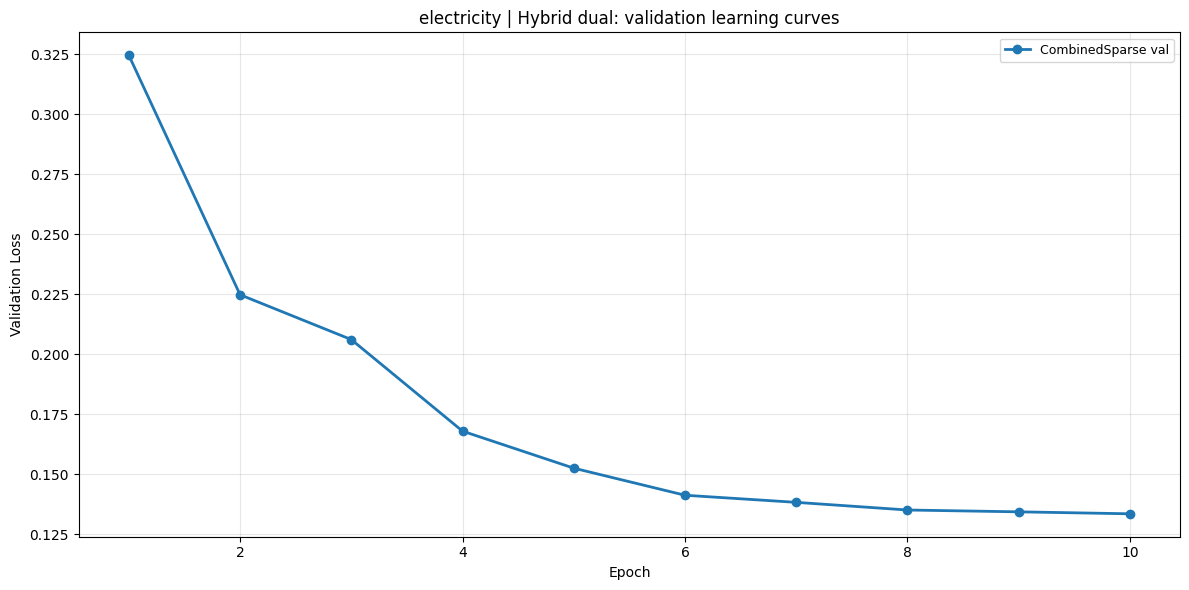

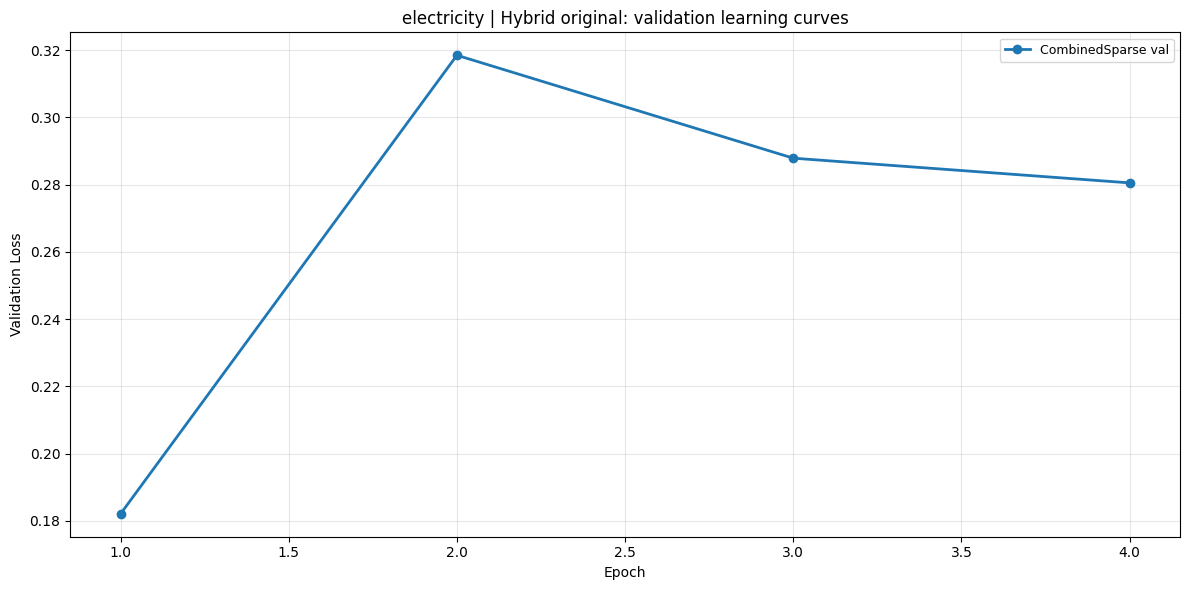

Saved learning-curve plots to: /teamspace/studios/this_studio/lightning_runs/SimpleTM_HybridFeatureAblation_Results/learning_curves


In [7]:
import matplotlib.pyplot as plt

MAX_LEARNING_CURVES_TO_SHOW = 12
LEARNING_CURVE_DIR = os.path.join(OUTPUT_DIR, "learning_curves")
os.makedirs(LEARNING_CURVE_DIR, exist_ok=True)

epoch_pattern = re.compile(
    r"Epoch:\s*(?P<epoch>\d+),\s*Steps:\s*\d+\s*\|\s*"
    r"Train Loss:\s*(?P<train>[0-9.eE+-]+)\s*"
    r"Vali Loss:\s*(?P<vali>[0-9.eE+-]+)\s*"
    r"Test Loss:\s*(?P<test>[0-9.eE+-]+)"
)

learning_rows = []
for log_path in sorted(glob.glob(os.path.join(OUTPUT_DIR, "logs", "*.log"))):
    stem = os.path.splitext(os.path.basename(log_path))[0]
    dataset_name, attention_mode, config_tag = stem.split("_", 2)
    repeat = 0
    previous_epoch = 0
    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            match = epoch_pattern.search(line)
            if not match:
                continue
            epoch = int(match.group("epoch"))
            if previous_epoch and epoch <= previous_epoch:
                repeat += 1
            previous_epoch = epoch
            learning_rows.append({
                "Dataset": dataset_name,
                "AttentionMode": attention_mode,
                "HybridConfig": config_tag,
                "Repeat": repeat,
                "Epoch": epoch,
                "TrainLoss": float(match.group("train")),
                "ValiLoss": float(match.group("vali")),
                "TestLoss": float(match.group("test")),
                "LogFile": log_path,
            })

learning_df = pd.DataFrame(learning_rows)
if learning_df.empty:
    print("No epoch-wise learning curves found. Run the training cell first.")
else:
    learning_csv = os.path.join(OUTPUT_DIR, "learning_curves.csv")
    learning_df.to_csv(learning_csv, index=False)
    print(f"Saved learning-curve data to: {learning_csv}")
    display(learning_df.head(20))

    shown = 0
    for (dataset_name, attention_mode), curve_df in learning_df.groupby(["Dataset", "AttentionMode"]):
        fig, ax = plt.subplots(figsize=(12, 6))
        for config_tag, mode_df in curve_df.groupby("HybridConfig"):
            mode_df = mode_df.groupby("Epoch", as_index=False)[["TrainLoss", "ValiLoss", "TestLoss"]].mean().sort_values("Epoch")
            ax.plot(mode_df["Epoch"], mode_df["ValiLoss"], marker="o", linewidth=2.0, label=f"{config_tag} val")

        ax.set_title(f"{dataset_name} | Hybrid {attention_mode}: validation learning curves")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation Loss")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)
        plt.tight_layout()
        curve_path = os.path.join(LEARNING_CURVE_DIR, f"{dataset_name}_{attention_mode}_validation_learning_curve.png")
        plt.savefig(curve_path, dpi=180, bbox_inches="tight")
        if shown < MAX_LEARNING_CURVES_TO_SHOW:
            plt.show()
            shown += 1
        else:
            plt.close(fig)

    print(f"Saved learning-curve plots to: {LEARNING_CURVE_DIR}")

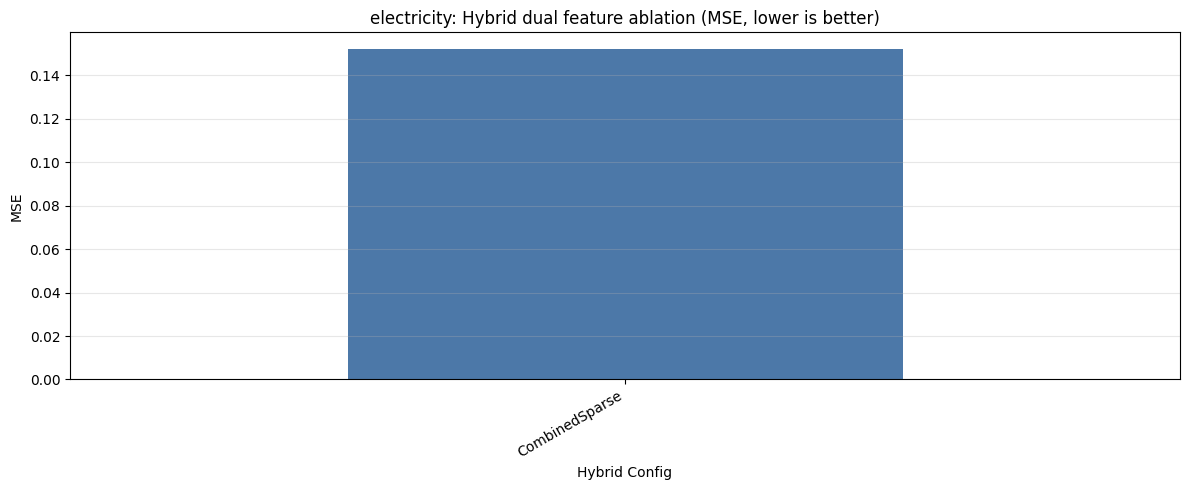

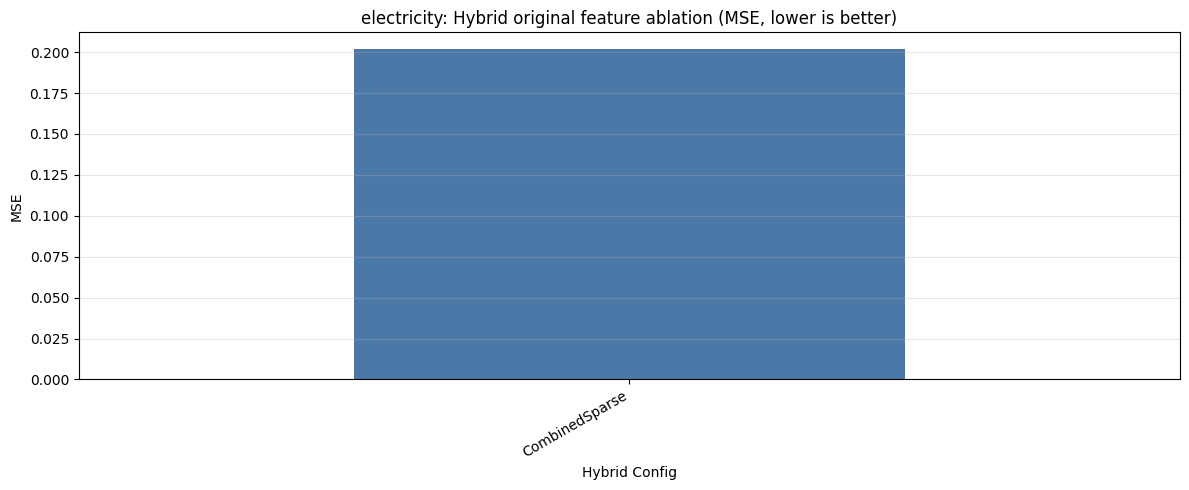

Best config by MSE:


,Dataset,AttentionMode,HybridConfig,MSE,MAE
0,electricity,dual,CombinedSparse,0.152107,0.246608
1,electricity,original,CombinedSparse,0.202007,0.288208


In [8]:
if "agg_df" in globals() and not agg_df.empty:
    metric = "MSE" if "MSE" in agg_df.columns else value_columns[0]
    for dataset_name, ds_df in agg_df.groupby("Dataset"):
        for attention_mode, mode_df in ds_df.groupby("AttentionMode"):
            plot_df = mode_df.set_index("HybridConfig")[[metric]].sort_values(metric)
            ax = plot_df.plot(kind="bar", figsize=(12, 5), legend=False, color="#4C78A8")
            ax.set_title(f"{dataset_name}: Hybrid {attention_mode} feature ablation ({metric}, lower is better)")
            ax.set_xlabel("Hybrid Config")
            ax.set_ylabel(metric)
            ax.grid(axis="y", alpha=0.3)
            plt.xticks(rotation=30, ha="right")
            plt.tight_layout()
            plot_path = os.path.join(OUTPUT_DIR, f"{dataset_name}_{attention_mode}_hybrid_feature_{metric}.png")
            plt.savefig(plot_path, dpi=180, bbox_inches="tight")
            plt.show()

    best_rows = agg_df.sort_values(["Dataset", "AttentionMode", metric]).groupby(["Dataset", "AttentionMode"], as_index=False).first()
    print(f"Best config by {metric}:")
    display(best_rows[["Dataset", "AttentionMode", "HybridConfig", metric, "MAE"] if "MAE" in best_rows.columns else ["Dataset", "AttentionMode", "HybridConfig", metric]])

In [9]:
print("Packing logs, checkpoints, plots, and CSV results...")
archive_path = shutil.make_archive(os.path.join(BASE_DIR, "SimpleTM_HybridFeatureAblation_Results"), "zip", OUTPUT_DIR)
print(f"DONE. Archive saved to: {archive_path}")
print("Download it from the Lightning file browser or copy it from the studio workspace.")


Packing logs, checkpoints, plots, and CSV results...
DONE. Archive saved to: /teamspace/studios/this_studio/lightning_runs/SimpleTM_HybridFeatureAblation_Results.zip
Download it from the Lightning file browser or copy it from the studio workspace.
